# **Modelo Phi-four**

> Autor: Camila Borges Sena

> E-mail: camila19sena@gmail.com

O que o código faz? Esse código implementa e resolve numericamente a dinâmica temporal de um campo escalar no modelo phi-4, com uma modificação chamada de derivada conformável (dependente do parâmetro α).

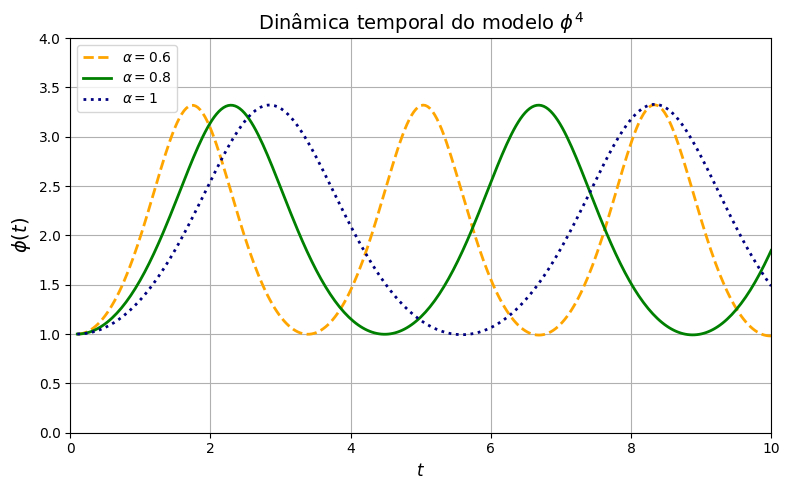

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# Parâmetros do modelo phi^4
# -----------------------------
m2 = -1.0
lam = 1.0

# mínimo clássico
phi0 = np.sqrt(-6 * m2 / lam)

# Tempo
t_span = (0.1, 10)
t_vals = np.linspace(*t_span, 300)

# Valores de alpha
alphas = [0.6, 0.8, 1.0]
colors = ['orange', 'green', 'navy']
styles = ['--', '-', ':']
labels = [r'$\alpha = 0.6$', r'$\alpha = 0.8$', r'$\alpha = 1$']

# -----------------------------
# Equação (9): α² φ¨ + m² φ + λ/6 φ³ = 0
# -----------------------------
def conformable_phi4(t, y, alpha):
    phi, dphi = y
    ddphi = -(m2 * phi + (lam / 6.0) * phi**3) / (alpha**2)
    return [dphi, ddphi]

# -----------------------------
# Gráfico
# -----------------------------
plt.figure(figsize=(8, 5))

for alpha, color, style, label in zip(alphas, colors, styles, labels):
    sol = solve_ivp(
        conformable_phi4,
        t_span,
        y0=[1.0, 0.0],  # condição inicial
        t_eval=t_vals,
        args=(alpha,)
    )

    plt.plot(sol.t, sol.y[0], style,
             color=color, linewidth=2, label=label)

plt.xlabel(r'$t$', fontsize=12)
plt.ylabel(r'$\phi(t)$', fontsize=14)
plt.xlim(0, 10)
plt.ylim(0, 4)
plt.title(r'Dinâmica temporal do modelo $\phi^4$', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


$\alpha = 0.6$: frequência ≈ 0.303 Hz
$\alpha = 0.8$: frequência ≈ 0.227 Hz
$\alpha = 1$: frequência ≈ 0.180 Hz


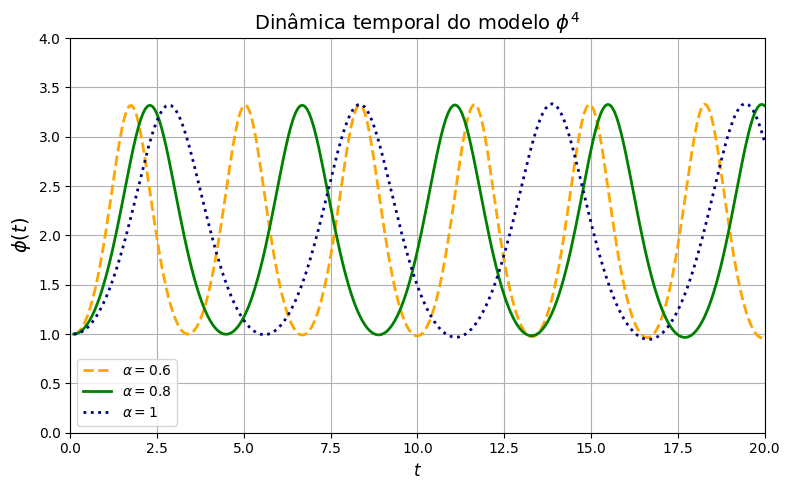

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

# -----------------------------
# Parâmetros do modelo φ⁴
# -----------------------------
m2 = -1.0   # parâmetro de massa ao quadrado (negativo → potencial com mínimo não trivial)
lam = 1.0   # acoplamento quartico

# mínimo clássico do potencial (valor em torno do qual o campo oscila)
phi0 = np.sqrt(-6 * m2 / lam)

# Intervalo de tempo da simulação
t_span = (0.1, 20)
t_vals = np.linspace(*t_span, 300)

# Valores de α (parâmetro conformável que altera a dinâmica)
alphas = [0.6, 0.8, 1.0]
colors = ['orange', 'green', 'navy']
styles = ['--', '-', ':']
labels = [r'$\alpha = 0.6$', r'$\alpha = 0.8$', r'$\alpha = 1$']

# -----------------------------
# Equação diferencial:
# α² φ¨ + m² φ + λ/6 φ³ = 0
# -----------------------------
def conformable_phi4(t, y, alpha):
    phi, dphi = y
    # cálculo da segunda derivada (aceleração do campo)
    ddphi = -(m2 * phi + (lam / 6.0) * phi**3) / (alpha**2)
    return [dphi, ddphi]

# -----------------------------
# Função para calcular frequência
# -----------------------------
def calcular_frequencia(sol):
    phi = sol.y[0]   # valores de φ(t)
    t = sol.t        # pontos de tempo

    # encontrar picos (máximos locais) da função φ(t)
    peaks, _ = find_peaks(phi)

    # se houver pelo menos dois picos, calcular período médio
    if len(peaks) > 1:
        periodos = np.diff(t[peaks])       # diferença entre tempos de picos consecutivos
        periodo_medio = np.mean(periodos)  # período médio
        frequencia = 1.0 / periodo_medio   # f = 1/T
        return frequencia
    else:
        return None

# -----------------------------
# Gráfico da evolução temporal
# -----------------------------
plt.figure(figsize=(8, 5))

for alpha, color, style, label in zip(alphas, colors, styles, labels):
    # resolver a EDO para cada valor de α
    sol = solve_ivp(
        conformable_phi4,
        t_span,
        y0=[1.0, 0.0],  # condição inicial: φ(0)=1, φ˙(0)=0
        t_eval=t_vals,
        args=(alpha,)
    )

    # plotar φ(t) para cada α
    plt.plot(sol.t, sol.y[0], style,
             color=color, linewidth=2, label=label)

    # calcular frequência média das oscilações
    freq = calcular_frequencia(sol)
    if freq:
        print(f"{label}: frequência ≈ {freq:.3f} Hz")
    else:
        print(f"{label}: não foi possível calcular a frequência")

# ajustes do gráfico
plt.xlabel(r'$t$', fontsize=12)
plt.ylabel(r'$\phi(t)$', fontsize=14)
plt.xlim(0, 20)
plt.ylim(0, 4)
plt.title(r'Dinâmica temporal do modelo $\phi^4$', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
